# Lab 9: Diffusion on Networks

This lab introduces **diffusion on networks**, the process by which different phenomena are transmitted through a network. We will particularly focus on visualization and simulation of certain diffusion processes, so we can understand their properties. We consider in this lab:
1. Review of linear diffusion
2. Bass / SI (Susceptible-Immune) diffusion
3. Percolation
4. Cascades and fragility

In [280]:
# Setup
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Review of Linear Diffusion

Load same Input-Output table as in assignment and let us study linear diffusion. We consider the Leontief production network setting with $n$ sectors:
\begin{align*}
    y_i & = d_i + \sum_{j=1}^{n} A_{i,j} \cdot y_j + \varepsilon_i \\
    y & = d + A y + \varepsilon
\end{align*}
- $y_i$ is total output of sector $i$. Outputs for $n$ sectors stacked into $y$
- $d_i$ is final demand for output of the sector $i$ and $d$ is collected final demand
- $A$ represents production structure: inputs needed to produce a unit of output

Consider shocking sector "D351 - Electric power generation, transmission and distribution" by a 10% decrease to its output. Let us trace how this affects activity of that sector and the sector "C28 - Manufacture of Machinery and Equipment", as well as aggregate output.

In [281]:
# Load UK IO Table from Excel sheet
io_table = pd.read_excel('UK_IO_Table.xlsx', sheet_name='IO_Table', header=0, index_col=0)
industry_labels = io_table.columns.tolist()
n = len(industry_labels)
A = io_table.values

# Load industry names from the same Excel file to match labels
industry_names = pd.read_excel('UK_IO_Table.xlsx', sheet_name='Original', header=5, usecols=range(2), nrows=n, index_col=0)
name_list = industry_names.iloc[:, 0].tolist()

Total output for each industry: [1.48705081 0.69097043 0.57711877 0.50001848 0.55501002 0.66211042
 0.64268349 0.86450414 0.69535765 0.52861728 0.68532229 0.72675234
 0.61598775 0.84150424 0.72994362 0.55624836 0.54837566 0.55342698
 0.50691352 0.5027788  0.62855758 0.74013634 0.65877333 1.09358465
 0.55303859 0.55053582 0.60201363 0.58243375 0.75346147 0.5471656
 0.70178683 0.99278904 0.57561406 0.59844658 0.67294644 0.60347701
 1.00584022 0.818301   0.6452727  0.97487256 0.8108004  0.63993691
 0.62065834 0.55372268 0.53860251 0.6275771  0.55340503 0.5666449
 0.91523759 3.60273939 2.09965283 0.69549812 0.63453245 0.78361819
 0.6053302  1.72402974 1.01824048 3.21266154 1.42512029 0.62364445
 1.73591694 0.58217128 0.77354045 1.50693152 1.09977651 0.6388375
 0.69183437 0.56841308 0.80452448 0.99084467 1.6420548  0.68718699
 2.29355968 0.94390558 1.31234698 0.54480248 0.5        1.13745044
 1.07255937 1.21933117 1.17673639 1.06323102 0.71802055 1.07154944
 1.03897691 0.52778989 1.13282169

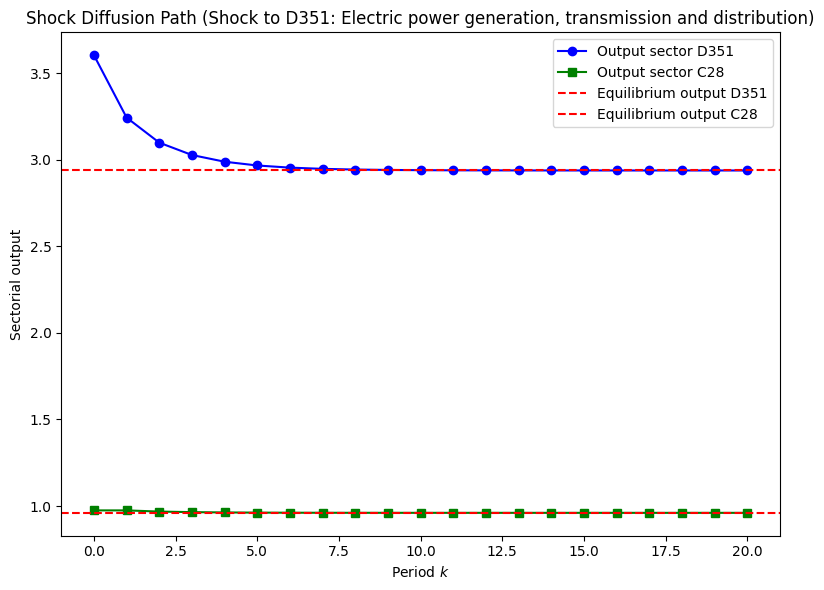

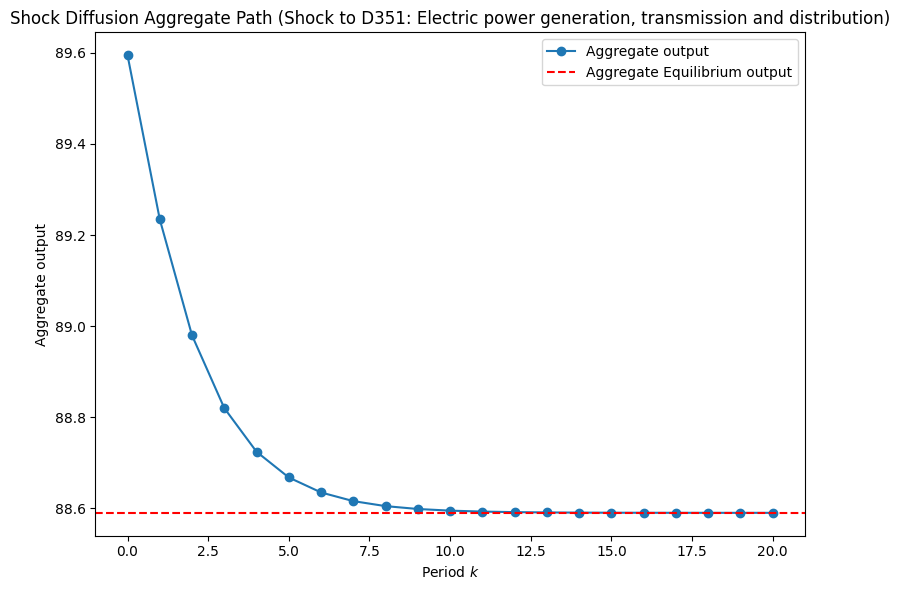

In [282]:
# Calculate total output for each industry (given an internal demand)
final_demand = 0.5 * np.ones(n)                              # Assume final demand is 50% of total for each industry
total_output = np.linalg.solve(np.eye(n) - A, final_demand)  # Total output from Leontief inverse
print("Total output for each industry:", total_output)

# Initialize a shock to a basis vector
i_code = 'D351'
i = industry_labels.index(i_code)
i_name = name_list[i]
basis_shock = np.zeros(n)
basis_shock[i] = -1 * 0.1 * total_output[i]                                          # 10% negative shock to the output of sector i

# Code for alternative sector
j_code = 'C28'
j = industry_labels.index(j_code)
j_name = name_list[j]

# Apply iterative shock propagation using the adjacency matrix over K = 20 periods
n_periods = 20 + 1                                                                   # Initial period (-1) plus 20 periods of propagation
output_sums = np.zeros(n_periods)
output_paths = np.zeros([n, n_periods])

# Initialize output vector as 100% of total output
output_paths[:, 0] = total_output                                                    # Initial output is equilibrium output
output_sums[0] = output_paths[:, 0].sum()                                            # Record initial output sum
output_paths[:, 1] = total_output + basis_shock                                      # Initial output is equilibrium output
output_sums[1] = output_paths[:, 1].sum()                                            # Record initial output sum
for k in range(2, n_periods):
    output_paths[:, k] = final_demand + A @ output_paths[:, k-1] + basis_shock       # Propagate shock through the network
    output_sums[k] = output_paths[:, k].sum()                                        # Record output sum at each period

# Calculate equilibrium output using inversion directly
equilibrium_output = np.linalg.solve(np.eye(n) - A, final_demand + basis_shock)
equilibrium_output_sum = equilibrium_output.sum()

# Plot path of total output of two sectors and compare to equlibrium output
plt.figure(figsize=(8, 6))
plt.plot(range(n_periods), output_paths[i], marker='o', color = 'blue', label=f'Output sector {i_code}')
plt.plot(range(n_periods), output_paths[j], marker='s', color = 'green', label=f'Output sector {j_code}')
plt.axhline(equilibrium_output[i], color='red', linestyle='--', label=f'Equilibrium output {i_code}')
plt.axhline(equilibrium_output[j], color='red', linestyle='--', label=f'Equilibrium output {j_code}')
plt.title(f'Shock Diffusion Path (Shock to {i_code}: {i_name})')
plt.xlabel('Period $k$')
plt.ylabel('Sectorial output')
plt.legend()
plt.tight_layout()
plt.show()

# Plot path of aggregate output and compare to aggregate equilibrium output
plt.figure(figsize=(8, 6))
plt.plot(range(n_periods), output_sums, marker='o', label='Aggregate output')
plt.axhline(equilibrium_output_sum, color='red', linestyle='--', label=f'Aggregate Equilibrium output')
plt.title(f'Shock Diffusion Aggregate Path (Shock to {i_code}: {i_name})')
plt.xlabel('Period $k$')
plt.ylabel('Aggregate output')
plt.legend()
plt.tight_layout()
plt.show()

Takeaways:
1. Impact of diffusion decreases every period
2. Decrease enforced by production structure
3. Total impact can be large due to compounded shock effect
4. Smooth transition from one equilibrium to another

## 

## Bass / SI non-linear diffusion

Recall main idea behind simple non-linear diffusion:
1. $F(t)$ are fraction of individuals who have adopted (purchased) a product at time $t$ (In terms of production networks application, $F(t)$ can be the fraction of sectors that experience a shock at time $t$.)
2. $p$ are early adopters (buy product even when others do not buy)
3. $q$ are imitators (buy product if they see others are buying it)

Change in adoption across time:
\begin{equation*}
    F(t+1) - F(t) = [p + q F(t)] \cdot [1 - F(t)]
\end{equation*}

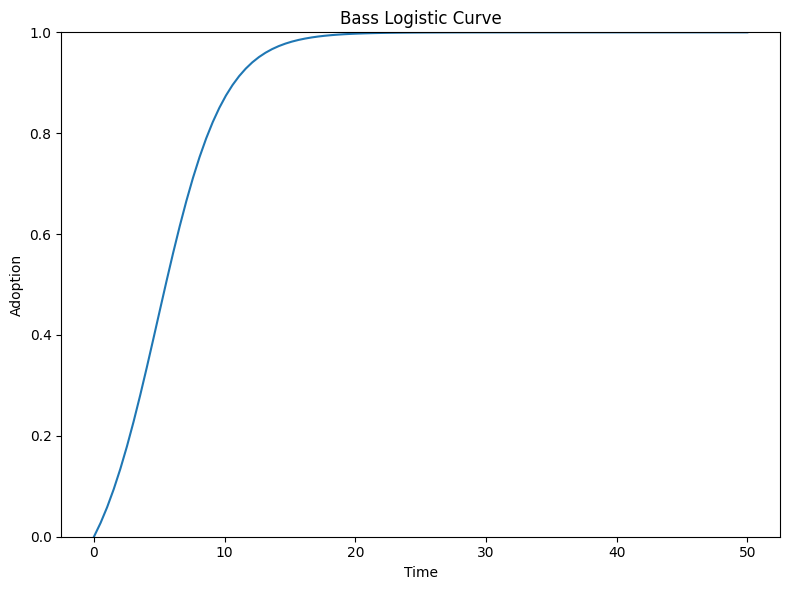

In [283]:
# Define Bass logistic curve
def bass_logistic(t, p, q):
    return (1 - np.exp(-(p + q) * t)) / (1 + (q / p) * np.exp(-(p + q) * t))

# Plot Bass logistic curve for different values of p and q
p, q = 0.05, 0.35           # Play around with these values (p early adoption, q imitation)
t = np.linspace(0, 50, 100)
plt.figure(figsize=(8, 6))
plt.plot(t, bass_logistic(t, p, q), label=f'p={p}, q={q}')
plt.title('Bass Logistic Curve')
plt.xlabel('Time')
plt.ylabel('Adoption')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Extensions to non-linear diffusion

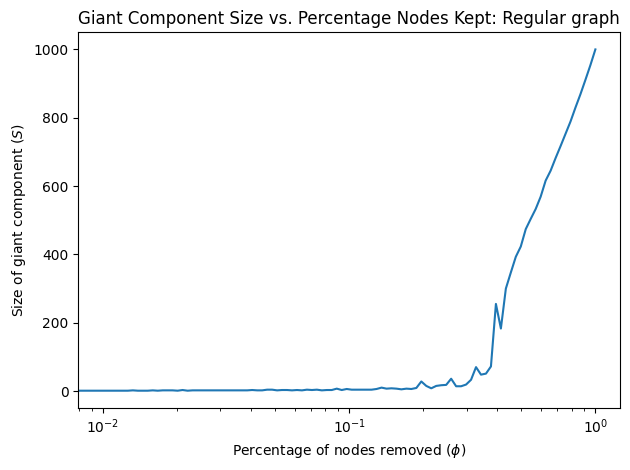

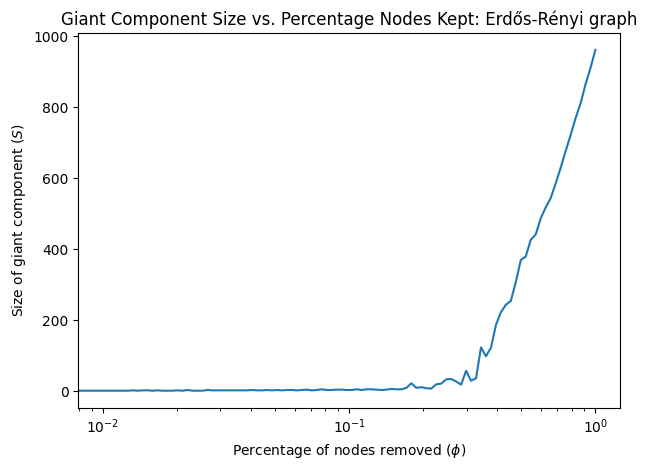

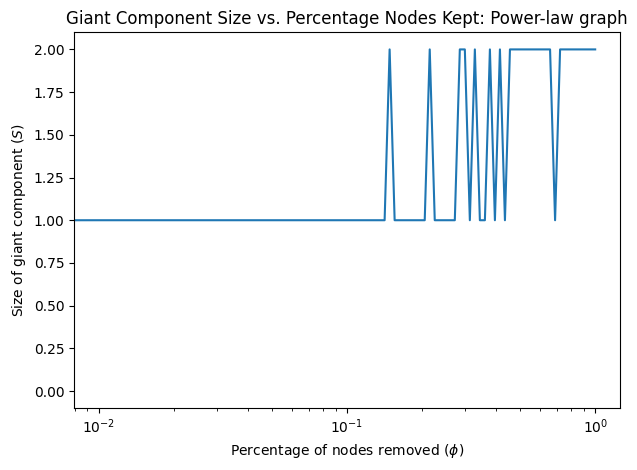

In [284]:
# Define function to remove a given percentage of nodes from a given graph
def remove_nodes_random(graph, percentage):
    n_nodes = graph.vcount()
    n_keep = int(percentage * n_nodes)
    n_remove = n_nodes - n_keep
    nodes_to_remove = np.random.choice(n_nodes, size=n_remove, replace=False)
    return graph.delete_vertices(nodes_to_remove)

# Divide graph by components and obtain size of giant (largest connected) component
def giant_component_size(graph):
    return graph.components().giant().vcount()

# Calculate size of giant component for a given graph after removing a (vector of) percentage of nodes
def giant_sizes(graph, percentages):
    # Preallocate array to store giant component sizes for each percentage
    n_percentages = len(percentages)
    sizes = np.zeros(n_percentages)
    for index, p in enumerate(percentages):
        # Make a copy of original graph and modify in-place by removing a percentage of nodes
        current_graph = graph.copy()
        remove_nodes_random(current_graph, p)
        
        # Calculate size of giant component, store and can now update current graph
        giant_size = giant_component_size(current_graph)
        sizes[index] = giant_size
    return sizes

# Plot size of giant component with respect to percentage of nodes removed for a given graph
def plot_giant_component(sizes, percentages, title, log_scale=True):
    plt.plot(percentages, sizes)
    if log_scale:
        plt.xscale('log')
    plt.xlabel('Percentage of nodes removed ($\\phi$)')
    plt.ylabel('Size of giant component ($S$)')
    plt.title('Giant Component Size vs. Percentage Nodes Kept: ' + title)
    plt.tight_layout()
    plt.show()

# Generate graphs from different models and report size of giant component with respect to percentage
n = 1000
n_grid = 100
log_scale = True # Choose log or linear scale for percentage of nodes removed
if log_scale:
    percentages = np.logspace(-2, 0, n_grid)
    percentages = np.concatenate(([0], percentages))
else:
    percentages = np.linspace(0, 1, n_grid)

# Aim to generate a given critical probability
critical_probability = 0.3    # Can play around with this value

# Regular degree graph (critical_probability = 1 / (k - 1) for k-regular graph)
fixed_degree = int(1 / critical_probability + 1)
regular_graph = ig.Graph.K_Regular(n=n, k=fixed_degree)
giant_sizes_regular = giant_sizes(regular_graph, percentages)
plot_giant_component(giant_sizes_regular, percentages, title='Regular graph', log_scale=log_scale)

# Erdős-Rényi graph
p_edge = 1 / (critical_probability * (n - 2))
er_graph = ig.Graph.Erdos_Renyi(n=n, p=p_edge)
giant_sizes_er = giant_sizes(er_graph, percentages)
plot_giant_component(giant_sizes_er, percentages, title='Erdős-Rényi graph', log_scale=log_scale)

# Power-law graph
exponent = 2.5  # Can play around with this value (exponent of power-law degree distribution)
power_law_graph = ig.Graph.Static_Power_Law(n=n, m=6, exponent=exponent)
giant_sizes_power_law = giant_sizes(power_law_graph, percentages)
plot_giant_component(giant_sizes_power_law, percentages, title='Power-law graph', log_scale=log_scale)

In [285]:
# Similar plots but removing nodes with highest degree instead of random removal
def remove_nodes_highest_degree(graph, max_degree):
    degree_sequence = np.array(graph.degree())
    nodes_to_remove = np.where(degree_sequence > max_degree)
    return graph.delete_vertices(nodes_to_remove)

# Calculate size of giant component for a given graph after removing a (vector of) percentage of nodes
def giant_sizes(graph, percentages):
    # Preallocate array to store giant component sizes for each percentage
    n_percentages = len(percentages)
    sizes = np.zeros(n_percentages)
    for index, p in enumerate(percentages):
        # Make a copy of original graph and modify in-place by removing a percentage of nodes
        current_graph = graph.copy()
        remove_nodes_highest_degree(current_graph, p)
        
        # Calculate size of giant component, store and can now update current graph
        giant_size = giant_component_size(current_graph)
        sizes[index] = giant_size
    return sizes

# Loop over the maximum degree to remove instead of percentage of nodes removed
max_degree = range(0, 20)

# Erdős-Rényi graph
max
giant_sizes_er = giant_sizes(er_graph, percentages)
plot_giant_component(er_graph, percentages, title='Erdős-Rényi graph', log_scale=log_scale)

# # Power-law graph
# power_law_graph = ig.Graph.Power_Law(n=n, m=5)
# giant_sizes_power_law = giant_sizes(power_law_graph, percentages)
# print("Giant component sizes for power-law graph:", giant_sizes_power_law)

TypeError: only non-negative integers, strings or igraph.Vertex objects can be converted to vertex IDs